## Predictive Regression
#### Name : Dipesh Ghimire | CNET ID : dipeshg | Date: February 10, 2026

This notebook implements 2-stage regression for predicting hedged CDS
spread “returns” using boxcar and discounted least squares for the predictive
phase, and compare the two.

In [1]:
import json
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import nasdaqdatalink
import numpy as np
import pandas as pd
import polars as pl
import scipy.stats as stats
from matplotlib.gridspec import GridSpec
from scipy.stats import ks_2samp, levene, ttest_1samp, wilcoxon

warnings.filterwarnings("ignore")

## Data Preprocessing

### Functions to Assist with Data Loading and Preprocessing

Helper functions used to build the merged panel:

1. **`load_cds_data(file_path)`**  
   Reads a tab-delimited CDS file (e.g. 5Y par spreads), sorts by ticker and date, and returns a pandas DataFrame with columns `date`, `ticker`, and `parspread`. Uses Polars for fast read, then converts to pandas and drops any empty column.

2. **`load_nasdaq_daily_data(api_key, tickers, start_date, end_date)`**  
   Fetches daily adjusted closing prices from Nasdaq Data Link (table `NDAQ/USEDHADJ`) for the given tickers and date range. Returns a DataFrame with `date`, `ticker` (renamed from `symbol`), and `close_adj`. Uses pagination so all rows are retrieved.

3. **`create_full_calendar_ticker_grid(start_date, end_date, tickers)`**  
   Builds a DataFrame with one row per (date, ticker) for every calendar day from `start_date` to `end_date`. Used as the base grid so that weekends and holidays still have a row per ticker; CDS and equity data are later left-merged onto this grid and forward-filled within ticker.

In [2]:
def load_cds_data(file_path: str) -> pd.DataFrame:
    """
    Load CDS data from a tab-delimited file, sort by ticker and date,
    and return a DataFrame with 'date', 'ticker' and 'parspread'.

    Args:
        file_path (str): Path to the CDS data file.

    Returns:
        pd.DataFrame: DataFrame of CDS data with columns 'date', 'ticker' and 'parspread'.
    """
    cds_df = pl.read_csv(file_path, separator="\t")
    cds_df = cds_df.sort(["ticker", "date"])
    cds_df = cds_df.to_pandas().drop(columns=[""])
    cds_df = cds_df[["date", "ticker", "parspread"]]
    return cds_df


def load_nasdaq_daily_data(
    api_key: str,
    tickers: list[str],
    start_date: str,
    end_date: str,
) -> pd.DataFrame:
    """
    Load daily NASDAQ adjusted closing price data for given tickers and date range,
    returning a DataFrame with columns 'date', 'ticker' and 'close_adj'.

    Args:
        api_key (str): Nasdaq Data Link API key.
        tickers (list[str]): List of ticker symbols.
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.

    Returns:
        pd.DataFrame: DataFrame containing daily NASDAQ data with columns 'date', 'ticker' and 'close_adj'.
    """
    nasdaqdatalink.ApiConfig.api_key = api_key
    nasdaq_df = nasdaqdatalink.get_table(
        "NDAQ/USEDHADJ",
        symbol=tickers,
        date={"gte": start_date, "lte": end_date},
        paginate=True,
    )
    nasdaq_df = nasdaq_df.sort_values(["symbol", "date"])
    nasdaq_df = nasdaq_df.rename(columns={"symbol": "ticker"})
    nasdaq_df = nasdaq_df[["date", "ticker", "close_adj"]]
    return nasdaq_df


def create_full_calendar_ticker_grid(
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    tickers: list[str],
) -> pd.DataFrame:
    """
    Build a DataFrame with one row per (date, ticker) for every calendar day in range.

    Use this as the base grid so that non-trading days (weekends, holidays) still
    have a row per ticker; actual time series can then be left-merged and
    forward-filled within ticker.

    Parameters
    ----------
    start_date : pd.Timestamp
        First calendar date (inclusive).
    end_date : pd.Timestamp
        Last calendar date (inclusive).
    tickers : list[str]
        List of ticker symbols to expand over dates.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns ['date', 'ticker'] and one row per (date, ticker).
    """
    calendar_dates = pd.date_range(start=start_date, end=end_date, freq="D")
    full_index = pd.MultiIndex.from_product(
        [calendar_dates, tickers],
        names=["date", "ticker"],
    )
    return full_index.to_frame(index=False)

### Data Loading and Preparation

This section loads the inputs needed for the merged panel:

1. **CDS data**: Load 5-year CDS par spreads from `data/Liq5YCDS.delim` (date, ticker, parspread).
2. **API key**: Read the Nasdaq Data Link API key from `keys/nasdaq_data_link.json` for equity and SPY downloads.
3. **Equity data**: Fetch daily adjusted closing prices from Nasdaq for every ticker in the CDS set, over the CDS date range.
4. **SPY data**: Fetch daily adjusted closing prices for the SPY ETF over the same date range (market proxy).
5. **Full grid**: Build a calendar × ticker grid with `create_full_calendar_ticker_grid` so we have one row per (date, ticker) for every calendar day in range, enabling non-trading days to be included and later forward-filled.

Tickers and the date range are driven by the CDS dataset so that equity, SPY, and the grid align.

In [3]:
# Load CDS data
cds_data = load_cds_data("data/Liq5YCDS.delim")

# Load private API keys from JSON file
with open("keys/nasdaq_data_link.json", "r") as file:
    api_keys = json.load(file)["api_key"]

# Load NASDAQ data for required tickers and date range
equity_data = load_nasdaq_daily_data(
    api_keys,
    sorted(set(cds_data.ticker)),
    cds_data.date.min(),
    cds_data.date.max(),
)

# Load SPY data for required date range
spy_data = load_nasdaq_daily_data(
    api_keys,
    ["SPY"],
    cds_data.date.min(),
    cds_data.date.max(),
)

# Build full grid: one row per (calendar date, ticker) so we keep all calendar days.
full_grid = create_full_calendar_ticker_grid(
    start_date=cds_data.date.min(),
    end_date=cds_data.date.max(),
    tickers=sorted(set(cds_data.ticker)),
)

### Data Cleaning and Merging

This section builds the unified panel used for analysis:

1. **Date handling**: Convert all date columns to `datetime` for correct merging and time-based indexing.
2. **SPY preparation**: Drop the ticker column and rename adjusted close to `spy_close_adj` (SPY is common to all tickers).
3. **Left merges** (so every calendar day × ticker from `full_grid` is kept):
   - Attach CDS `parspread` on `(date, ticker)`.
   - Attach equity `close_adj` on `(date, ticker)`.
   - Attach SPY on `date` (same value for all tickers per date).
4. **Forward-fill** `parspread`, `close_adj`, and `spy_close_adj` within each ticker so non-trading days get the last known value.
5. **Drop** rows that still have NaNs (e.g. leading days before first observation per ticker), then **sort** by ticker and date and **set date as index** for time-series use.

The result is `final_data`: one row per (date, ticker) for all calendar days in range, with date as the index.

In [4]:
# Convert all date columns to datetime objects for proper merging and time-based indexing
for df in (cds_data, equity_data, spy_data, full_grid):
    df["date"] = pd.to_datetime(df["date"])

# Prepare SPY data: remove ticker column and rename adjusted close column for clarity
spy_data = spy_data.drop(columns=["ticker"])
spy_data = spy_data.rename(columns={"close_adj": "spy_close_adj"})

# 1. Left-merge CDS data so all (date, ticker) pairs are preserved from full_grid
merged_data = pd.merge(full_grid, cds_data, on=["date", "ticker"], how="left")

# 2. Merge equity data on (date, ticker)
merged_data = pd.merge(merged_data, equity_data, on=["date", "ticker"], how="left")

# 3. Merge SPY data on date (applies equally to all tickers for a given date)
merged_data = pd.merge(merged_data, spy_data, on="date", how="left")

# Forward-fill values within each ticker group to propagate last known values to non-trading days
for col in ("parspread", "close_adj", "spy_close_adj"):
    merged_data[col] = merged_data.groupby("ticker")[col].ffill()
    
# Remove any rows that still contain NaNs
final_data = merged_data.dropna()

# Sort for tidy time-series indexing, then set date as index
final_data = final_data.sort_values(by=["ticker", "date"]).set_index("date")

### Wednesday Returns for Predictive Regression

We restrict the analysis to **Wednesdays** to obtain a consistent weekly sampling interval. For each Wednesday we compute:

- **CDS spread return**: percent change in `parspread` from the previous Wednesday (per ticker).
- **Equity return**: percent change in adjusted close from the previous Wednesday (per ticker).
- **Market return**: percent change in SPY adjusted close from the previous Wednesday (per ticker).

The result is a panel of weekly returns (`returns_data`) with one row per (Wednesday, ticker); rows with missing returns (e.g. first Wednesday per ticker) are dropped.

In [5]:
# Add the day of the week as a column based on the DataFrame's DateTime index
final_data["day_of_week"] = final_data.index.day_name()

# Filter rows to keep only Wednesdays, for consistent interval analysis
wednesday_data = final_data[final_data["day_of_week"] == "Wednesday"].copy()

# Compute weekly percent change for CDS spreads, equity, and market (SPY) prices per ticker
wednesday_data["cds_spread_return"] = (
    wednesday_data.groupby("ticker")["parspread"].pct_change()
)
wednesday_data["equity_return"] = (
    wednesday_data.groupby("ticker")["close_adj"].pct_change()
)
wednesday_data["market_return"] = (
    wednesday_data.groupby("ticker")["spy_close_adj"].pct_change()
)

# Select only the required columns for analysis
returns_data = wednesday_data[
    ["ticker", "cds_spread_return", "equity_return", "market_return"]
].copy()

# Drop any remaining rows with missing values
returns_data.dropna(inplace=True)

# Display the returns_data DataFrame
display(returns_data)

,ticker,cds_spread_return,equity_return,market_return
date,,,,
2018-01-10,AES,-0.028747,-0.008341,0.013495
2018-01-17,AES,-0.030953,-0.005523,0.020028
2018-01-24,AES,-0.120536,0.041025,0.012770
2018-01-31,AES,0.009136,0.047532,-0.004521
2018-02-07,AES,0.081617,-0.093414,-0.050478
...,...,...,...,...
2025-12-03,XRX,-0.053254,0.018997,0.006195
2025-12-10,XRX,0.054431,-0.033184,0.005381
2025-12-17,XRX,-0.013924,0.030467,-0.023516


## Models

This section implements the two-stage regression framework described in the assignment.

**Stage 1 — Contemporaneous hedging (boxcar OLS, K=16):**
1. Form the CDS index return $r^{\text{Index}}_n$ as the cross-sectional arithmetic mean of all $r^{\text{CDS}}_{E,n}$ each Wednesday.
2. For each ticker $E$ and each week $n \geq K+1$, calibrate using the **previous** $K$ weeks:
   - **Equity CAPM** (eq. 2): $r^{\text{Equity}}_E \sim m$, yielding $\gamma_{E,n}$. Residual equity return: $c_{E,n} = r^{\text{Equity}}_{E,n} - \gamma_{E,n} m_n$.
   - **CDS contemporaneous** (eq. 3): $r^{\text{CDS}}_E \sim r^{\text{Equity}}_E + r^{\text{Index}}$, yielding $\beta^{(n)}_{E,\text{Equity}},\ \beta^{(n)}_{E,\text{Index}}$. Hedge portfolio: $f_{E,n} = \beta^{(n)}_{E,\text{Equity}}\, r^{\text{Equity}}_{E,n} + \beta^{(n)}_{E,\text{Index}}\, r^{\text{Index}}_n$. Residual (hedged) CDS return: $\rho_{E,n} = r^{\text{CDS}}_{E,n} - f_{E,n}$.

**Stage 2 — Predictive regression (comparing boxcar K=16 vs. exponential half-life=12):**
$$\rho_{E,n} \sim c_{E,n-1} + \varepsilon$$
yielding $\mu_{E,n}$ and predictive residuals $q_{E,n} = \rho_{E,n} - \mu_{E,n-1}\, c_{E,n-1}$.

**Key implementation notes:**
- All regressions are **no-intercept** (the HW defines $f$ purely as $\beta \cdot$ predictors, and $c,\rho$ as simple arithmetic differences).
- The coefficient for row $n$ is estimated on rows $n-K, \ldots, n-1$, then applied to row $n$ — there is strictly zero look-ahead.
- The predictive residual $q_{E,n}$ uses $\mu_{E,n-1}$ (computed up through row $n-1$) and $c_{E,n-1}$, as given out in eq. (8).

In [6]:
# ------- Regression Parameters -------
K_CONTEMP   = 16      # boxcar window for both contemporaneous regressions
K_PRED_BOX  = 16      # boxcar window for predictive regression
HL_PRED_EXP = 12.0    # half-life (weeks) for exponential predictive regression
MIN_OBS     = 4       # footnote 4: start at 4 & 3 so early regressions are nontrivial

### Core regression utilities

| Function | Purpose |
|---|---|
| `ols_no_intercept` | Multivariate no-intercept OLS via `numpy.linalg.lstsq` |
| `wls_no_intercept` | Same but with a weight vector (used for discounted LS) |

We use no-intercept throughout because the HW defines $f_{E,n}$ as a pure linear combination of predictors and defines $c$, $\rho$ by simple arithmetic subtraction. Inserting a constant would change the economic meaning of the residuals.

For the exponential scheme, observation at age $a$ (0 = most recent, $a$ increases going back) receives weight
$$w_a = \left(\tfrac{1}{2}\right)^{a / h}$$
where $h$ is the half-life. This is passed directly into `wls_no_intercept`.

In [7]:
def ols_no_intercept(y: np.ndarray, X: np.ndarray) -> np.ndarray:
    """
    No-intercept OLS:  beta = argmin ||y - X @ beta||^2
    Uses lstsq for numerical stability.  Returns beta of shape (p,).
    """
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return beta


def wls_no_intercept(y: np.ndarray, X: np.ndarray, w: np.ndarray) -> np.ndarray:
    """
    Weighted no-intercept least squares.

    Equivalent to OLS on sqrt(w)*y ~ sqrt(w)*X, which is standard WLS.
    Weights do NOT need to be normalised.
    """
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    w = np.asarray(w, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    sw = np.sqrt(w).reshape(-1, 1)
    return ols_no_intercept(sw.ravel() * y, sw * X)


def exp_weights(n: int, half_life: float) -> np.ndarray:
    """
    Exponential weights for a window of length n.
    Index 0 = oldest observation, index n-1 = most recent.
    w_i = 0.5 ^ ( (n-1-i) / half_life )  =>  w_{n-1} = 1  (most recent).
    """
    ages = np.arange(n - 1, -1, -1, dtype=float)   # n-1, n-2, ..., 1, 0
    return 0.5 ** (ages / half_life)

### CDS index return

The CDS index return $r^{\text{Index}}_n$ is the **arithmetic average** of all individual CDS spread returns across tickers for each Wednesday. This is a simple cross-sectional mean and it is computed every week.

In [8]:
# Build weekly panel from returns_data
wk = returns_data.reset_index().copy()
wk['date'] = pd.to_datetime(wk['date'])
wk = wk.sort_values(['ticker', 'date']).reset_index(drop=True)

# CDS index return: arithmetic cross-sectional mean each Wednesday
r_index_ser = (
    wk.groupby('date')['cds_spread_return']
      .mean()
      .rename('index_return')
)
wk = wk.merge(r_index_ser.reset_index(), on='date', how='left')

### Stage 1 - Contemporaneous regressions

For each ticker $E$ and each week $n$ (starting at $K+1 = 17$), we estimate two regressions on the **previous** $K=16$ weeks:

**Model A — Equity CAPM (eq. 2):**
$$r^{\text{Equity}}_{E} \sim m$$
Coefficient $\gamma_{E,n}$ is the rolling market beta of the stock. The **residual equity return** is:
$$c_{E,n} = r^{\text{Equity}}_{E,n} - \gamma_{E,n}\, m_n$$

**Model B — CDS factor model (eq. 3):**
$$r^{\text{CDS}}_{E} \sim r^{\text{Equity}}_E + r^{\text{Index}}$$
Coefficients $\beta^{(n)}_{E,\text{Equity}},\ \beta^{(n)}_{E,\text{Index}}$ are used to form the **hedge portfolio return** (the contemporaneous prediction):
$$f_{E,n} = \beta^{(n)}_{E,\text{Equity}}\, r^{\text{Equity}}_{E,n} + \beta^{(n)}_{E,\text{Index}}\, r^{\text{Index}}_n$$
and the **residual (hedged) CDS return**:
$$\rho_{E,n} = r^{\text{CDS}}_{E,n} - f_{E,n}$$

In [9]:
def run_contemporaneous(df_ticker: pd.DataFrame, K: int = K_CONTEMP) -> pd.DataFrame:
    """
    Run contemporaneous rolling regressions (CAPM for equity and CDS factor model) for a single ticker.

    Parameters
    ----------
    df_ticker : pd.DataFrame
        DataFrame for one ticker, sorted by date. Must include:
        'date', 'ticker', 'cds_spread_return', 'equity_return',
        'market_return', 'index_return'.
    K : int
        Rolling window size (number of weeks).

    Returns
    -------
    pd.DataFrame
        The original DataFrame with these additional columns:
        - gamma:     Rolling CAPM (market) beta for equity
        - c:         Equity return residual (r_eq - gamma * m)
        - beta_eq:   Slope of CDS ~ equity regression (no intercept)
        - beta_ix:   Slope of CDS ~ index regression (no intercept)
        - f:         Predicted CDS from equity and index (hedge portfolio)
        - rho:       CDS residual (hedged): r_cds - f
    """
    df = df_ticker.reset_index(drop=True).copy()
    N = len(df)

    # Pre-allocate results arrays
    gamma   = np.full(N, np.nan)
    c       = np.full(N, np.nan)
    beta_eq = np.full(N, np.nan)
    beta_ix = np.full(N, np.nan)
    f       = np.full(N, np.nan)
    rho     = np.full(N, np.nan)

    r_eq_arr   = df['equity_return'].to_numpy(dtype=float)
    m_arr      = df['market_return'].to_numpy(dtype=float)
    r_cds_arr  = df['cds_spread_return'].to_numpy(dtype=float)
    r_ix_arr   = df['index_return'].to_numpy(dtype=float)

    for n in range(K, N):
        # Rolling window: uses [n-K, n) (K rows ending before row n)
        sl = slice(n - K, n)
        r_eq_win  = r_eq_arr[sl]
        m_win     = m_arr[sl]
        r_cds_win = r_cds_arr[sl]
        r_ix_win  = r_ix_arr[sl]

        # Model A: Rolling CAPM regression for equity (r_eq ~ m, no intercept)
        mask_a = np.isfinite(r_eq_win) & np.isfinite(m_win)
        if mask_a.sum() >= MIN_OBS:
            g = ols_no_intercept(r_eq_win[mask_a], m_win[mask_a])[0]
            gamma[n] = g
            if np.isfinite(r_eq_arr[n]) and np.isfinite(m_arr[n]):
                c[n] = r_eq_arr[n] - g * m_arr[n]

        # Model B: Rolling CDS factor regression (r_cds ~ r_eq + r_ix)
        X_win = np.column_stack([r_eq_win, r_ix_win])
        mask_b = np.isfinite(r_cds_win) & np.isfinite(X_win).all(axis=1)
        if mask_b.sum() >= MIN_OBS:
            betas = ols_no_intercept(r_cds_win[mask_b], X_win[mask_b])
            be, bi = float(betas[0]), float(betas[1])
            beta_eq[n] = be
            beta_ix[n] = bi
            if (np.isfinite(r_eq_arr[n]) and np.isfinite(r_ix_arr[n])
                and np.isfinite(r_cds_arr[n])):
                f[n]   = be * r_eq_arr[n] + bi * r_ix_arr[n]
                rho[n] = r_cds_arr[n] - f[n]

    df['gamma']   = gamma
    df['c']       = c
    df['beta_eq'] = beta_eq
    df['beta_ix'] = beta_ix
    df['f']       = f
    df['rho']     = rho
    return df


# Apply rolling regressions to each ticker
stage1_parts = []
for tkr, grp in wk.groupby('ticker', sort=True):
    grp_sorted = grp.sort_values('date').reset_index(drop=True)
    stage1_parts.append(run_contemporaneous(grp_sorted, K=K_CONTEMP))

stage1 = pd.concat(stage1_parts, ignore_index=True)
stage1 = stage1.sort_values(['ticker', 'date']).reset_index(drop=True)


# Show first 5 rows (with computed values) for a sample ticker
sample_tkr = stage1['ticker'].unique()[0]
cols_show = [
    'date', 'ticker', 'equity_return', 'market_return', 'gamma', 'c',
    'cds_spread_return', 'beta_eq', 'beta_ix', 'f', 'rho'
]
sample_df = stage1.loc[(stage1['ticker'] == sample_tkr) & stage1['rho'].notna(), cols_show].head(5)
sample_df = sample_df.style.set_caption(f"First 5 rows for {sample_tkr}")
display(sample_df)

,date,ticker,equity_return,market_return,gamma,c,cds_spread_return,beta_eq,beta_ix,f,rho
16,2018-05-02 00:00:00,AES,0.024027,-0.001628,0.531699,0.024892,-0.022162,-0.948284,0.564787,-0.002892,-0.019270
17,2018-05-09 00:00:00,AES,-0.009776,0.023934,0.557610,-0.023122,-0.043247,-0.991244,0.541678,-0.003909,-0.039338
18,2018-05-16 00:00:00,AES,0.017332,0.010166,0.524851,0.011996,0.000726,-0.962527,0.616499,0.002793,-0.002066
19,2018-05-23 00:00:00,AES,-0.007332,0.004115,0.477129,-0.009296,-0.006514,-0.710666,0.712718,0.011723,-0.018236
20,2018-05-30 00:00:00,AES,0.039431,-0.002743,0.505259,0.040817,0.033760,-0.876460,0.726922,0.000824,0.032936


### Stage 2 - Predictive regression: $\rho_{E,n} \sim c_{E,n-1}$

We now treat the residuals from Stage 1 as the input to a predictive regression. The economic intuition is:

> After stripping out the contemporaneous effect of equity and the credit index (i.e., removing the contemporaneous hedge), does last week's *idiosyncratic* equity move ($c_{E,n-1}$) predict this week's *idiosyncratic* CDS widening ($\rho_{E,n}$)?

This is a one-lag, one-variable, no-intercept rolling regression estimated in two flavors:

| Variant | Window / weight |
|---|---|
| Boxcar | Uniform weights over last 16 observations |
| Exponential | Exponentially decaying weights, half-life = 12 weeks |

Per eq. (8), the **predictive residual** is:
$$q_{E,n} = \rho_{E,n} - \mu_{E,n-1}\, c_{E,n-1}$$
where $\mu_{E,n-1}$ is estimated using data **up to** row $n-1$ and $c_{E,n-1}$ is the equity residual from the **previous** week.

In [10]:
def run_predictive(
    df_ticker: pd.DataFrame,
    K_box: int = K_PRED_BOX,
    hl_exp: float = HL_PRED_EXP,
) -> pd.DataFrame:
    """
    Compute predictive regression of rho_n ~ c_{n-1} (no intercept) for a single ticker.
    Both boxcar (uniform window) and exponential (decaying weights) versions
    are estimated recursively.

    At each time n, the model uses the most recent K_box valid training pairs (rho_i, c_{i-1})
    for i up to n, fitting:
        mu[n] = argmin_y sum w_i * (rho_i - mu * c_{i-1})^2

    Predictive residual for each n:
        q[n] = rho[n] - mu[n-1] * c[n-1]
    (mu lags by one for valid predictive residuals.)

    Parameters
    ----------
    df_ticker : pandas.DataFrame
        Sorted by date, must include 'rho' and 'c' columns for one ticker.
    K_box : int
        Window size for boxcar regression.
    hl_exp : float
        Half-life for exponential weighting.

    Returns
    -------
    DataFrame containing the original columns plus:
        - mu_box, mu_exp: estimated predictive slope at each time
        - q_box, q_exp: predictive residuals, using lagged mu and c
    """
    df = df_ticker.reset_index(drop=True).copy()
    N = len(df)

    rho = df['rho'].values.astype(float)
    c = df['c'].values.astype(float)

    # Build lagged predictor: c_lag[n] = c[n-1]
    c_lag = np.empty(N)
    c_lag[0] = np.nan
    c_lag[1:] = c[:-1]

    mu_box = np.full(N, np.nan)
    mu_exp = np.full(N, np.nan)

    for n in range(1, N):
        # Prepare training data up to and including row n
        y = rho[1 : n + 1]      # rho_1 .. rho_n
        x = c_lag[1 : n + 1]    # c_0   .. c_{n-1}

        valid = np.isfinite(y) & np.isfinite(x)
        if valid.sum() < MIN_OBS:
            continue

        y_valid = y[valid]
        x_valid = x[valid]

        # Boxcar regression: use last K_box valid pairs
        n_obs = min(K_box, len(y_valid))
        y_b = y_valid[-n_obs:]
        x_b = x_valid[-n_obs:]
        mu_box[n] = ols_no_intercept(y_b, x_b)[0]

        # Exponential regression: last K_box pairs with exponential weights
        y_e = y_valid[-n_obs:]
        x_e = x_valid[-n_obs:]
        w_e = exp_weights(n_obs, hl_exp)
        mu_exp[n] = wls_no_intercept(y_e, x_e, w_e)[0]

    # Lag mu estimates to align with correct c[n-1]
    mu_box_lag = np.empty(N)
    mu_box_lag[0] = np.nan
    mu_box_lag[1:] = mu_box[:-1]
    mu_exp_lag = np.empty(N)
    mu_exp_lag[0] = np.nan
    mu_exp_lag[1:] = mu_exp[:-1]

    q_box = rho - mu_box_lag * c_lag
    q_exp = rho - mu_exp_lag * c_lag

    df['mu_box'] = mu_box
    df['mu_exp'] = mu_exp
    df['q_box'] = q_box
    df['q_exp'] = q_exp
    return df


# Run predictive regression per ticker and combine results for the full panel
stage2_parts = []
for tkr, grp in stage1.groupby('ticker', sort=True):
    grp_sorted = grp.sort_values('date').reset_index(drop=True)
    stage2_parts.append(run_predictive(grp_sorted))

panel = pd.concat(stage2_parts, ignore_index=True)
panel = panel.sort_values(['ticker', 'date']).reset_index(drop=True)


# Display first valid predictive rows for a single ticker
sample_tkr = panel['ticker'].unique()[0]
sample_df = panel.loc[
    (panel['ticker'] == sample_tkr) & panel['q_box'].notna(),
    ['date', 'ticker', 'rho', 'c', 'mu_box', 'mu_exp', 'q_box', 'q_exp']
].head(5)
sample_df.style.set_caption(f"First 5 predictive rows for {sample_tkr}")

,date,ticker,rho,c,mu_box,mu_exp,q_box,q_exp
21,2018-06-06 00:00:00,AES,0.030205,-0.006296,-0.073262,0.004248,0.073138,0.073496
22,2018-06-13 00:00:00,AES,0.104700,0.050348,-0.285627,-0.240068,0.104238,0.104726
23,2018-06-20 00:00:00,AES,-0.018283,-0.016201,-0.320558,-0.301456,-0.003903,-0.006197
24,2018-06-27 00:00:00,AES,-0.001436,0.014180,-0.302316,-0.281219,-0.006629,-0.006320
25,2018-07-04 00:00:00,AES,0.014168,-0.014578,-0.259335,-0.229484,0.018455,0.018156


## Analysis

We now compare the performance of the **boxcar** and **exponential** predictive regressions across several dimensions:

1. **Unconditional distribution** : mean, std, skewness, excess kurtosis, tail quantiles.
2. **Time-series of cross-sectional MSE** : identifies historical regimes where one estimator dominates the other.
3. **Tail behavior** : histogram overlay and quantile-quantile plot.
4. **Per-ticker heterogeneity** : which names drive differences.
5. **Distribution of $\mu$** : how the predictive coefficient itself behaves under the two schemes.

**Economic intuition:** The boxcar estimator weights all $K$ observations equally, giving it good statistical efficiency in calm markets but slow reaction to structural breaks. The exponential estimator down-weights old observations, tracking regime changes faster at the cost of higher estimation noise. We would expect the exponential weighting to have lower residual variance during stress episodes (financial crises, rating events) when credit-equity co-movement changes abruptly, while the boxcar should be competitive in stable, low-volatility periods.

### Pooled distributional statistics

In [11]:
def describe_residuals(series: pd.Series, label: str) -> pd.Series:
    """
    Compute summary statistics for a residual series.

    Parameters
    ----------
    series : pd.Series
        Series of residuals.
    label : str
        Name for the output Series.

    Returns
    -------
    pd.Series
        Summary statistics for the provided residual series.
    """
    s = series.dropna()
    return pd.Series(
        {
            "N": len(s),
            "Mean": s.mean(),
            "Std": s.std(ddof=1),
            "Skewness": float(stats.skew(s)),
            "Ex. Kurtosis": float(stats.kurtosis(s)),
            "p1%": s.quantile(0.01),
            "p5%": s.quantile(0.05),
            "p25%": s.quantile(0.25),
            "Median": s.median(),
            "p75%": s.quantile(0.75),
            "p95%": s.quantile(0.95),
            "p99%": s.quantile(0.99),
            "IQR": s.quantile(0.75) - s.quantile(0.25),
            "|p99|/|p1|": abs(s.quantile(0.99)) / max(abs(s.quantile(0.01)), 1e-12),
        },
        name=label,
    )

# Compute summary statistics for predictive residuals pooled across all tickers
pooled_stats = pd.concat(
    [
        describe_residuals(panel["q_box"], "Boxcar"),
        describe_residuals(panel["q_exp"], "Exponential"),
    ],
    axis=1,
)

display(pooled_stats.style.set_caption("Pooled predictive residual statistics (all tickers)"))

,Boxcar,Exponential
N,6641.000000,6641.000000
Mean,-0.000442,-0.000609
Std,0.079501,0.081983
Skewness,-0.948927,-2.675295
Ex. Kurtosis,272.002028,314.656713
p1%,-0.164483,-0.163055
p5%,-0.072849,-0.072800
p25%,-0.023051,-0.023198
Median,-0.001361,-0.001377
p75%,0.020986,0.020944


### Cross-sectional MSE over time

For each Wednesday $t$ we compute the cross-sectional mean squared residual:
$$\text{MSE}_t^{\text{box}} = \frac{1}{N_t} \sum_E q_{E,t}^2, \qquad
\text{MSE}_t^{\text{exp}} = \frac{1}{N_t} \sum_E q_{E,t}^2$$
and the signed difference $\Delta_t = \text{MSE}_t^{\text{exp}} - \text{MSE}_t^{\text{box}}$. Weeks with $\Delta_t < 0$ are periods where the exponential estimator produced tighter predictions.

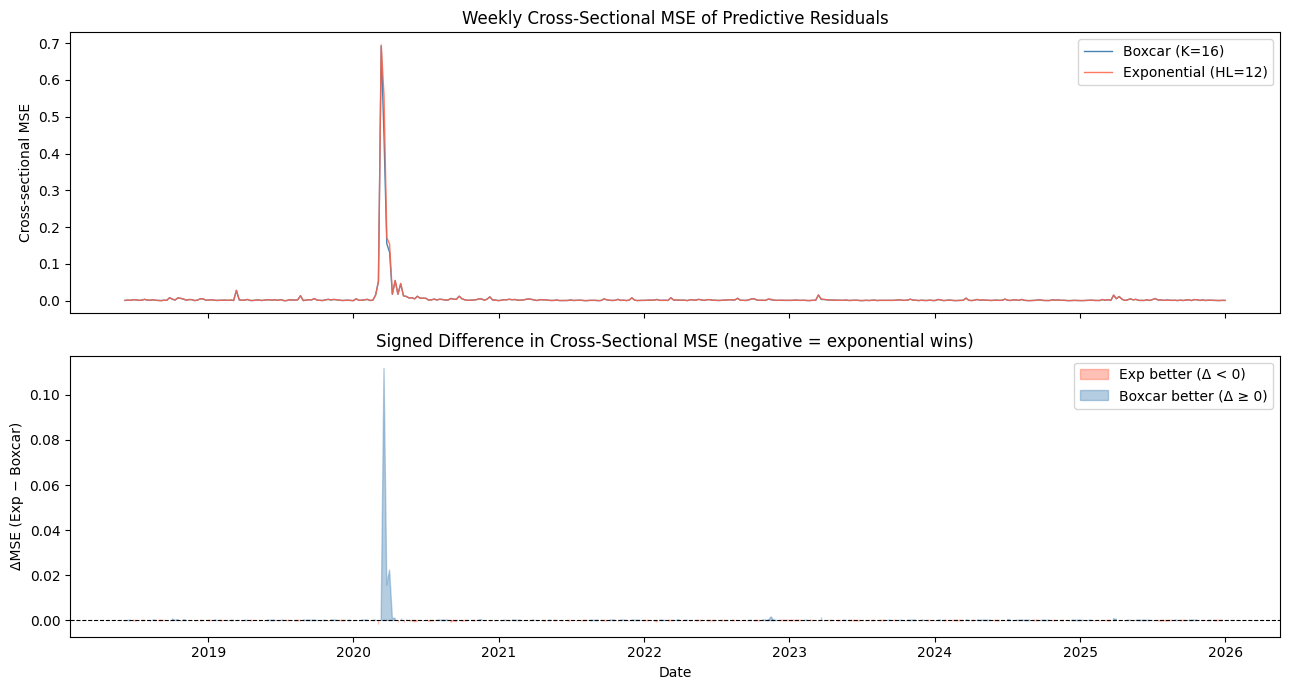

,Count,Percent,Value
Exponential better,192,48.5%,
Boxcar better,204,51.5%,
Avg ΔMSE,,,+0.000396


In [12]:
def cross_sectional_mse(grp: pd.DataFrame) -> pd.Series:
    """
    Compute cross-sectional mean squared error (MSE) for both Boxcar and
    Exponential predictive residuals within a group (single date).
    Returns NaN for MSEs with no data.
    """
    q_box = grp["q_box"].dropna()
    q_exp = grp["q_exp"].dropna()
    return pd.Series(
        {
            "mse_box": (q_box ** 2).mean() if len(q_box) else np.nan,
            "mse_exp": (q_exp ** 2).mean() if len(q_exp) else np.nan,
            "n_tickers": max(len(q_box), len(q_exp)),
        }
    )


# Compute weekly MSEs grouped by date, dropping weeks with missing values for either estimator
weekly_mse = (
    panel.groupby("date", group_keys=False)
    .apply(cross_sectional_mse)
    .dropna(subset=["mse_box", "mse_exp"])
)

# Ensure the index is a DatetimeIndex
weekly_mse.index = pd.to_datetime(weekly_mse.index)

# Compute delta: positive means Boxcar is better, negative means Exponential is better
weekly_mse["delta"] = weekly_mse["mse_exp"] - weekly_mse["mse_box"]

# Plot weekly MSE time series (top) and their signed difference (bottom)
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Top panel: MSE time series for both estimators
ax_top = axes[0]
ax_top.plot(
    weekly_mse.index, weekly_mse["mse_box"], lw=1.0, color="steelblue", label="Boxcar (K=16)"
)
ax_top.plot(
    weekly_mse.index,
    weekly_mse["mse_exp"],
    lw=1.0,
    color="tomato",
    alpha=0.85,
    label="Exponential (HL=12)",
)
ax_top.set_ylabel("Cross-sectional MSE")
ax_top.set_title("Weekly Cross-Sectional MSE of Predictive Residuals")
ax_top.legend()
ax_top.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Bottom panel: delta MSE, highlight which estimator wins each week
ax_bot = axes[1]
ax_bot.axhline(0, color="black", lw=0.8, ls="--")
ax_bot.fill_between(
    weekly_mse.index,
    weekly_mse["delta"],
    0,
    where=weekly_mse["delta"] < 0,
    color="tomato",
    alpha=0.40,
    label="Exp better (Δ < 0)",
)
ax_bot.fill_between(
    weekly_mse.index,
    weekly_mse["delta"],
    0,
    where=weekly_mse["delta"] >= 0,
    color="steelblue",
    alpha=0.40,
    label="Boxcar better (Δ ≥ 0)",
)
ax_bot.set_ylabel("ΔMSE (Exp − Boxcar)")
ax_bot.set_xlabel("Date")
ax_bot.set_title("Signed Difference in Cross-Sectional MSE (negative = exponential wins)")
ax_bot.legend()
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

# Calculate and print overall counts and win rates for each estimator
exp_wins = (weekly_mse["delta"] < 0).sum()
box_wins = (weekly_mse["delta"] >= 0).sum()
total_wks = len(weekly_mse)

# Create a DataFrame to summarize the win rates and average ΔMSE
win_rate_summary = pd.DataFrame({
    "Count": [
        exp_wins,
        box_wins,
        ""
    ],
    "Percent": [
        f"{100 * exp_wins / total_wks:.1f}%",
        f"{100 * box_wins / total_wks:.1f}%",
        ""
    ],
    "Value": [
        "",
        "",
        f"{weekly_mse['delta'].mean():+.6f}"
    ]
},
    index=["Exponential better", "Boxcar better", "Avg ΔMSE"]
)

# Set a title for display
win_rate_summary.style.set_caption(f"Weekly win rates ({total_wks} weeks with data)")

### Historical events — when does each method dominate?

We identify the 10 weeks where the MSE difference is most extreme in each direction. These "event weeks" can be mapped to known macroeconomic or credit-market events to understand when each estimator's adaptivity advantage matters most.

In [13]:
# Display the top 10 weeks where the exponential estimator most strongly outperformed boxcar (lowest ΔMSE)
top_exp_wins = (
    weekly_mse[["mse_box", "mse_exp", "delta", "n_tickers"]]
    .nsmallest(10, "delta")
)

# Display the top 10 weeks where the boxcar estimator most strongly outperformed exponential (highest ΔMSE)
top_box_wins = (
    weekly_mse[["mse_box", "mse_exp", "delta", "n_tickers"]]
    .nlargest(10, "delta")
)

# Display top 10 exponential wins
top_exp_wins_display = top_exp_wins.style.set_caption("Top 10 weeks — Exponential BEST (most negative ΔMSE)")
display(top_exp_wins_display)

# Display top 10 boxcar wins
top_box_wins_display = top_box_wins.style.set_caption("Top 10 weeks — Boxcar BEST (most positive ΔMSE)")
display(top_box_wins_display)

,mse_box,mse_exp,delta,n_tickers
date,,,,
2020-03-04 00:00:00,0.053252,0.051722,-0.001530,17.000000
2020-09-02 00:00:00,0.006367,0.005619,-0.000748,17.000000
2020-04-22 00:00:00,0.017880,0.017199,-0.000681,17.000000
2022-02-02 00:00:00,0.003580,0.002917,-0.000664,17.000000
2020-05-06 00:00:00,0.013296,0.012754,-0.000542,17.000000
2020-06-03 00:00:00,0.005254,0.004719,-0.000534,17.000000
2020-09-16 00:00:00,0.004069,0.003551,-0.000518,17.000000
2020-07-08 00:00:00,0.001867,0.001506,-0.000362,17.000000
2021-04-28 00:00:00,0.002564,0.002246,-0.000317,17.000000


,mse_box,mse_exp,delta,n_tickers
date,,,,
2020-03-18 00:00:00,0.445988,0.557633,0.111645,17.000000
2020-04-01 00:00:00,0.131937,0.154294,0.022357,17.000000
2020-03-25 00:00:00,0.155300,0.170975,0.015676,17.000000
2020-03-11 00:00:00,0.692378,0.694809,0.002431,17.000000
2022-11-16 00:00:00,0.002569,0.004183,0.001614,17.000000
2023-03-22 00:00:00,0.003295,0.004717,0.001422,17.000000
2020-04-29 00:00:00,0.045805,0.046944,0.001139,17.000000
2020-04-15 00:00:00,0.054488,0.055463,0.000975,17.000000
2020-04-08 00:00:00,0.017290,0.018215,0.000926,17.000000


### Tail behavior

Tail measure is critical for any strategy. We compare the tail distributions in two ways:
1. **Overlapping histograms** of pooled $q$ values.
2. **Quantile–quantile (QQ) plot** of exponential quantiles vs. boxcar quantiles — deviations from the 45° line indicate tail asymmetry between the two methods.

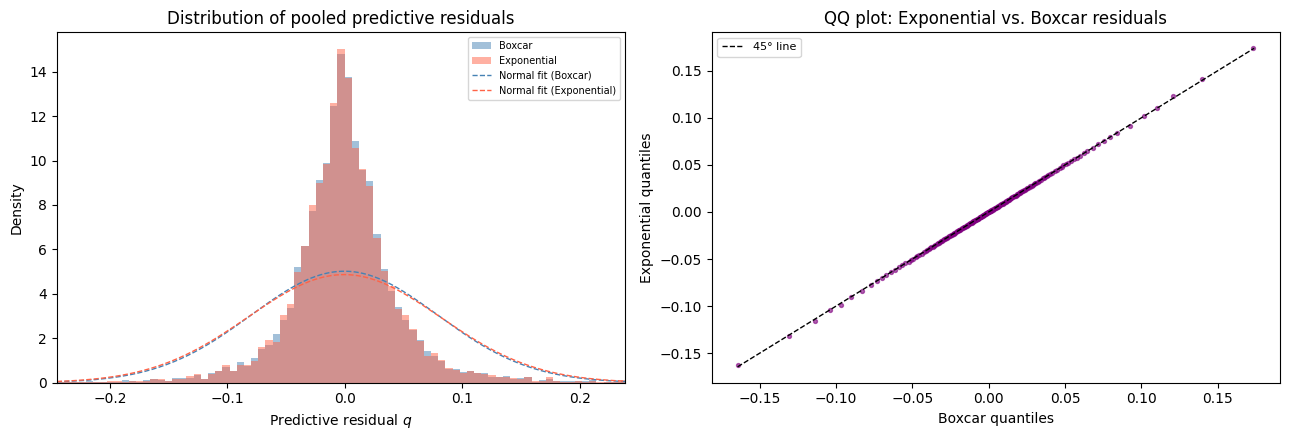

,Boxcar,Exponential,Ratio (Exp/Box)
Percentile,,,
1.000000,-0.164483,-0.163055,0.991318
2.500000,-0.103485,-0.104398,1.008821
5.000000,-0.072849,-0.072800,0.999315
95.000000,0.074856,0.075515,1.008799
97.500000,0.110122,0.110501,1.003441
99.000000,0.173414,0.173890,1.002748


In [14]:
# Prepare pooled predictive residuals for both estimators
q_box_pool = panel["q_box"].dropna().to_numpy()
q_exp_pool = panel["q_exp"].dropna().to_numpy()

# Bin edges for shared histogram: focus on central 99% to avoid extremes
lo = min(np.percentile(q_box_pool, 0.5), np.percentile(q_exp_pool, 0.5))
hi = max(np.percentile(q_box_pool, 99.5), np.percentile(q_exp_pool, 99.5))
bins = np.linspace(lo, hi, 80)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Histogram: Overlay both residual distributions with normal fits
ax_hist = axes[0]
ax_hist.hist(
    q_box_pool, bins=bins, density=True, alpha=0.5,
    color="steelblue", label="Boxcar", histtype="stepfilled"
)
ax_hist.hist(
    q_exp_pool, bins=bins, density=True, alpha=0.5,
    color="tomato", label="Exponential", histtype="stepfilled"
)

# Add dashed normal fit curves using empirical mean and std
x_ref = np.linspace(lo, hi, 400)
for arr, color, label in [
    (q_box_pool, "steelblue", "Boxcar"),
    (q_exp_pool, "tomato", "Exponential"),
]:
    pdf = stats.norm.pdf(x_ref, loc=arr.mean(), scale=arr.std())
    ax_hist.plot(
        x_ref, pdf, color=color, ls="--", lw=1.0, label=f"Normal fit ({label})"
    )

ax_hist.set_xlim(lo, hi)
ax_hist.set_xlabel("Predictive residual $q$")
ax_hist.set_ylabel("Density")
ax_hist.set_title("Distribution of pooled predictive residuals")
ax_hist.legend(fontsize=7)

# QQ plot: Compare tails between estimators
ax_qq = axes[1]
qs = np.linspace(0.01, 0.99, 200)
qb_vals = np.quantile(q_box_pool, qs)
qe_vals = np.quantile(q_exp_pool, qs)

ax_qq.scatter(qb_vals, qe_vals, s=8, color="purple", alpha=0.6, zorder=2)
line_min = min(qb_vals.min(), qe_vals.min())
line_max = max(qb_vals.max(), qe_vals.max())
ax_qq.plot(
    [line_min, line_max], [line_min, line_max],
    "k--", lw=1.0, label="45° line"
)
ax_qq.set_xlabel("Boxcar quantiles")
ax_qq.set_ylabel("Exponential quantiles")
ax_qq.set_title("QQ plot: Exponential vs. Boxcar residuals")
ax_qq.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Compare tail percentiles using a DataFrame
tail_ps = [1, 2.5, 5, 95, 97.5, 99]
qb_vals = [np.percentile(q_box_pool, p) for p in tail_ps]
qe_vals = [np.percentile(q_exp_pool, p) for p in tail_ps]
ratios = [qe / qb if abs(qb) > 1e-10 else float('nan') for qb, qe in zip(qb_vals, qe_vals)]

tail_df = pd.DataFrame({
    "Percentile": tail_ps,
    "Boxcar": qb_vals,
    "Exponential": qe_vals,
    "Ratio (Exp/Box)": ratios,
})

tail_df = tail_df.set_index("Percentile")
tail_df = tail_df.style.set_caption("Tail comparison (pooled residuals)")
display(tail_df)

### Per-ticker performance heterogeneity

Different names can behave very differently. Some issuers CDS can be more idiosyncratic and less predictable from equity moves, while others have a tighter structural link. We compute per-ticker MSE for both methods and examine the distribution of the MSE ratio.

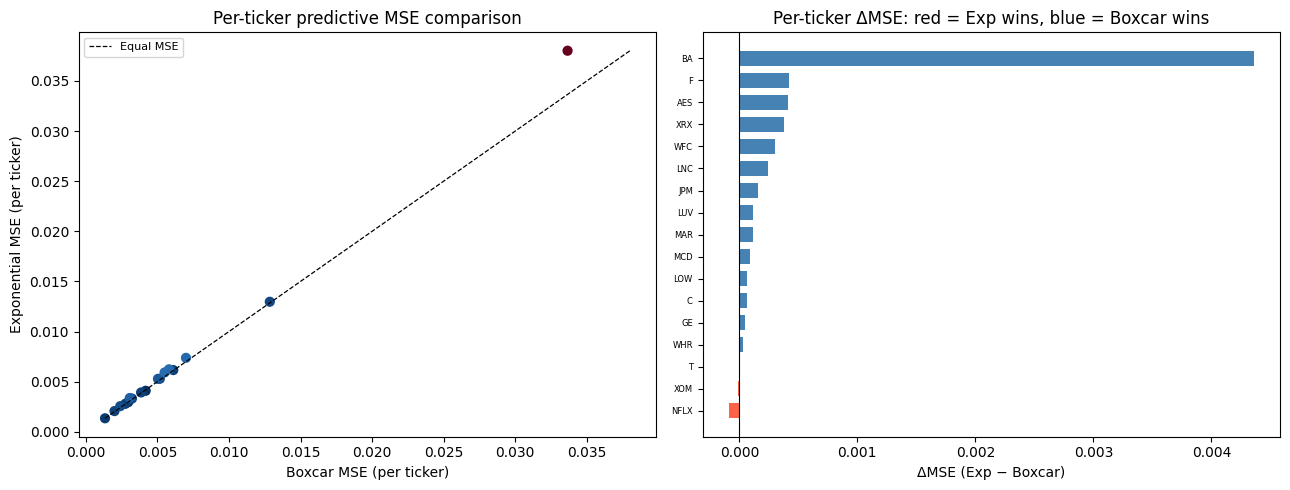

,MSE_boxcar,MSE_exp,delta_MSE,ratio_Exp_Box,N_obs
ticker,,,,,
NFLX,0.00418,0.00409,-0.00009,0.97858,305.00000
XOM,0.00296,0.00295,-0.00001,0.99646,396.00000
T,0.00134,0.00135,0.00000,1.00349,396.00000
WHR,0.00275,0.00279,0.00003,1.01214,396.00000
GE,0.00611,0.00616,0.00004,1.00721,396.00000
C,0.00200,0.00207,0.00006,1.03108,396.00000
LOW,0.00386,0.00392,0.00006,1.01631,396.00000
MCD,0.00322,0.00331,0.00009,1.02733,396.00000
MAR,0.00517,0.00529,0.00012,1.02281,396.00000


,Win Count,Percent
Exp better,2,11.8%
Box better,15,88.2%


In [15]:
def per_ticker_mse(group: pd.DataFrame) -> pd.Series:
    """
    Compute MSE metrics for a given ticker group.

    Returns:
        pd.Series with:
            - MSE_boxcar: Mean squared error of boxcar residuals
            - MSE_exp: Mean squared error of exponential residuals
            - delta_MSE: Difference (Exp - Boxcar)
            - ratio_Exp_Box: Ratio of Exp to Boxcar MSE
            - N_obs: Number of observations (max between methods)
    """
    qb = group['q_box'].dropna()
    qe = group['q_exp'].dropna()
    n_obs = max(len(qb), len(qe))

    mse_boxcar = (qb ** 2).mean() if len(qb) > 0 else np.nan
    mse_exp = (qe ** 2).mean() if len(qe) > 0 else np.nan
    delta_mse = mse_exp - mse_boxcar if not np.isnan(mse_exp) and not np.isnan(mse_boxcar) else np.nan
    ratio_exp_box = mse_exp / mse_boxcar if mse_boxcar and mse_boxcar > 1e-12 else np.nan

    return pd.Series({
        'MSE_boxcar': mse_boxcar,
        'MSE_exp': mse_exp,
        'delta_MSE': delta_mse,
        'ratio_Exp_Box': ratio_exp_box,
        'N_obs': n_obs,
    })

# Compute per-ticker performance metrics
ticker_perf = (
    panel.groupby('ticker', group_keys=False)
    .apply(per_ticker_mse)
    .sort_values('delta_MSE')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter plot: Compare MSE for each ticker under both estimators
ax_scatter = axes[0]
sc = ax_scatter.scatter(
    ticker_perf['MSE_boxcar'],
    ticker_perf['MSE_exp'],
    c=ticker_perf['delta_MSE'],
    cmap='RdBu_r',
    s=40,
    zorder=2
)
mse_min = min(ticker_perf['MSE_boxcar'].min(), ticker_perf['MSE_exp'].min())
mse_max = max(ticker_perf['MSE_boxcar'].max(), ticker_perf['MSE_exp'].max())
ax_scatter.plot([mse_min, mse_max], [mse_min, mse_max], 'k--', lw=0.9, label='Equal MSE')
ax_scatter.set_xlabel('Boxcar MSE (per ticker)')
ax_scatter.set_ylabel('Exponential MSE (per ticker)')
ax_scatter.set_title('Per-ticker predictive MSE comparison')
ax_scatter.legend(fontsize=8)

# Horizontal bar plot: ΔMSE sorted across tickers
ax_bar = axes[1]
bar_colors = ['tomato' if v < 0 else 'steelblue' for v in ticker_perf['delta_MSE']]
ax_bar.barh(
    range(len(ticker_perf)),
    ticker_perf['delta_MSE'],
    color=bar_colors,
    height=0.7
)
ax_bar.axvline(0, color='black', lw=0.8)
ax_bar.set_yticks(range(len(ticker_perf)))
ax_bar.set_yticklabels(ticker_perf.index, fontsize=6)
ax_bar.set_xlabel('ΔMSE (Exp − Boxcar)')
ax_bar.set_title('Per-ticker ΔMSE: red = Exp wins, blue = Boxcar wins')

plt.tight_layout()
plt.show()

# Display per-ticker result table
styled_perf = (
    ticker_perf.style
    .format("{:.5f}")
    .set_caption("Per-ticker performance, sorted by ΔMSE")
)
display(styled_perf)

# Show win counts for each method at ticker level
exp_wins = (ticker_perf['delta_MSE'] < 0).sum()
box_wins = (ticker_perf['delta_MSE'] >= 0).sum()
total_tickers = len(ticker_perf)

df_win_counts = pd.DataFrame({
    "Win Count": [exp_wins, box_wins],
    "Percent": [100 * exp_wins / total_tickers, 100 * box_wins / total_tickers],
}, index=["Exp better", "Box better"])
df_win_counts = df_win_counts.style.format({
    "Win Count": "{:d}",
    "Percent": "{:.1f}%"
}).set_caption("Ticker-level win count")
display(df_win_counts)

### Distribution of predictive coefficients $\mu$

Understanding the variation of $\mu_{E,n}$ across tickers and time helps us interpret the predictive signal. In this context, a negative $\mu$ means that an idiosyncratic increase in equity returns last week predicts idiosyncratic credit spread tightening this week. 

> The intuitive credit-equity relationship is : equity strength leads to credit improvement, causing spreads to narrow. If coefficients fluctuate wildly, it suggests noise; persistent negativity indicates a stable, intuitive link where equity outperformance precedes tighter credit spreads.

We also compare coefficient stability between the two estimators — the exponential estimator should exhibit higher time-series variance in $\mu$ since it reacts faster to new data.

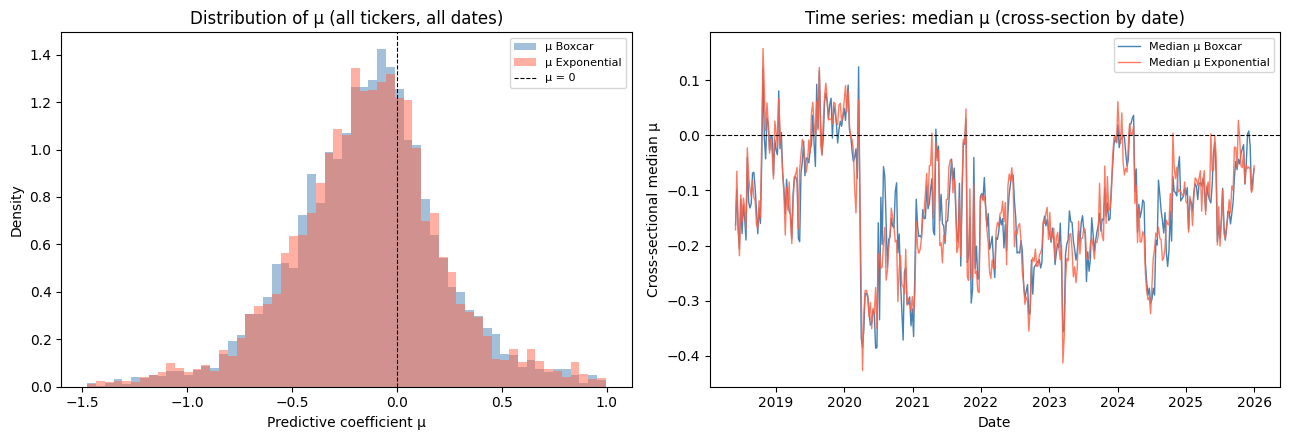

,μ Boxcar,μ Exponential
N,6658.000000,6658.000000
Mean,-0.147568,-0.147063
Std,0.449045,0.464821
Skewness,-1.351881,-1.803621
Ex. Kurtosis,18.366660,30.649437
p1%,-1.476069,-1.434889
p5%,-0.773858,-0.776344
p25%,-0.359960,-0.354294
Median,-0.126519,-0.130810
p75%,0.073077,0.072655


In [16]:
# --- Plot distribution and time series of predictive coefficients μ ---

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Extract and pool all available μ values for both estimators
mu_box_pool = panel["mu_box"].dropna().to_numpy()
mu_exp_pool = panel["mu_exp"].dropna().to_numpy()

# Determine histogram range based on central percentiles to limit outliers
lower = min(np.percentile(mu_box_pool, 1), np.percentile(mu_exp_pool, 1))
upper = max(np.percentile(mu_box_pool, 99), np.percentile(mu_exp_pool, 99))
bins = np.linspace(lower, upper, 60)

# -- Histogram: pooled μ across tickers and time --
ax_hist = axes[0]
ax_hist.hist(
    mu_box_pool,
    bins=bins,
    density=True,
    alpha=0.5,
    color="steelblue",
    label="μ Boxcar"
)
ax_hist.hist(
    mu_exp_pool,
    bins=bins,
    density=True,
    alpha=0.5,
    color="tomato",
    label="μ Exponential"
)
ax_hist.axvline(0, color="black", lw=0.8, ls="--", label="μ = 0")
ax_hist.set_xlabel("Predictive coefficient μ")
ax_hist.set_ylabel("Density")
ax_hist.set_title("Distribution of μ (all tickers, all dates)")
ax_hist.legend(fontsize=8)

# -- Time series: cross-sectional medians of μ by date --
ax_ts = axes[1]

# Group by date, compute median μ for both methods, drop dates with missing values
mu_ts = (
    panel.groupby("date")[["mu_box", "mu_exp"]]
    .median()
    .dropna()
)
mu_ts.index = pd.to_datetime(mu_ts.index)

ax_ts.plot(
    mu_ts.index,
    mu_ts["mu_box"],
    lw=1.0,
    color="steelblue",
    label="Median μ Boxcar"
)
ax_ts.plot(
    mu_ts.index,
    mu_ts["mu_exp"],
    lw=1.0,
    color="tomato",
    alpha=0.85,
    label="Median μ Exponential"
)
ax_ts.axhline(0, color="black", lw=0.8, ls="--")
ax_ts.set_xlabel("Date")
ax_ts.set_ylabel("Cross-sectional median μ")
ax_ts.set_title("Time series: median μ (cross-section by date)")
ax_ts.legend(fontsize=8)
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

# Print summary statistics for μ for both estimators
mu_stats = pd.concat(
    [
        describe_residuals(panel["mu_box"], "μ Boxcar"),
        describe_residuals(panel["mu_exp"], "μ Exponential"),
    ],
    axis=1,
)

mu_stats = mu_stats.style.set_caption("Predictive coefficient μ — distributional statistics:")
display(mu_stats)

### Statistical significance of the predictive coefficient $\mu$

1. **Is the pooled $\mu$ significantly different from zero?** : A one-sample $t$-test on the pooled (all tickers, all dates) $\mu$ values tests $H_0: \mathbb{E}[\mu] = 0$. Because the sample is large, even economically small deviations will reach significance; we therefore also report the effect size (Cohen's $d$).

2. **Is $\mu$ significantly different from zero ticker by ticker?** : For each ticker, we run a one-sample $t$-test on its time-series of $\mu$ values. We then summarise how many tickers reject $H_0$ at the 5 % and 1 % levels, giving a sense of how pervasive the predictive signal is across names.

3. **Non-parametric confirmation** : A Wilcoxon signed-rank test on the pooled $\mu$ provides a distribution-free alternative, robust to the heavy tails visible in the histogram.

,N,Mean μ,Std μ,t-statistic,t p-value,Cohen's d,Wilcoxon W,Wilcoxon p-value
μ Boxcar,"6,658",-0.147568,0.449045,-26.815,1.69e-150,-0.3286,6319685,1.17e-202
μ Exponential,"6,658",-0.147063,0.464821,-25.816,3.84e-140,-0.3164,6363588,5.60e-199


,Boxcar,Exponential
Tickers tested,17,17
Reject at 5%,16 (94.1%),16 (94.1%)
Reject at 1%,15 (88.2%),14 (82.4%)
Median p-value,0.0000,0.0000
Cross-ticker mean μ,-0.146473,-0.145962


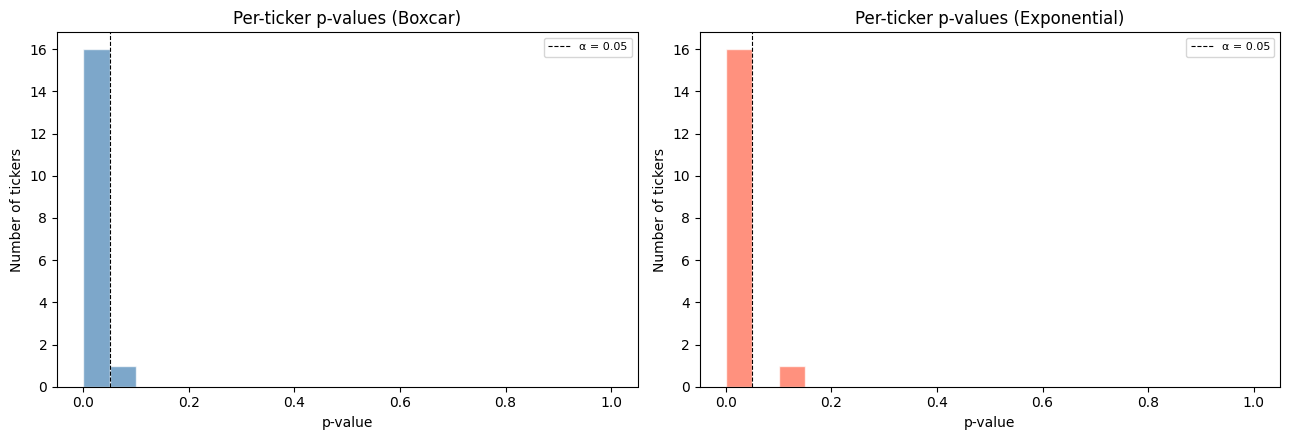

In [17]:
# --- Pooled (all tickers × all dates) significance ---

# Prepare pooled μ arrays (NaN removed)
mu_box_pool = panel["mu_box"].dropna().to_numpy()
mu_exp_pool = panel["mu_exp"].dropna().to_numpy()

def pooled_mu_tests(mu_values: np.ndarray, label: str) -> pd.DataFrame:
    """
    Perform one-sample t-test and Wilcoxon signed-rank test against zero for μ.
    Returns a one-row DataFrame with test summary statistics.
    """
    n = len(mu_values)
    mean = np.mean(mu_values)
    std = np.std(mu_values, ddof=1)
    t_stat, t_p = ttest_1samp(mu_values, popmean=0.0)
    cohen_d = mean / std if std > 0 else np.nan
    w_stat, w_p = wilcoxon(mu_values)
    return pd.DataFrame({
        "N": [n],
        "Mean μ": [mean],
        "Std μ": [std],
        "t-statistic": [t_stat],
        "t p-value": [t_p],
        "Cohen's d": [cohen_d],
        "Wilcoxon W": [w_stat],
        "Wilcoxon p-value": [w_p],
    }, index=[label])

# Collect the summary for both estimators
pooled_summary = pd.concat([
    pooled_mu_tests(mu_box_pool, "μ Boxcar"),
    pooled_mu_tests(mu_exp_pool, "μ Exponential"),
])

# Display formatted summary table for pooled t-tests and Wilcoxon tests
display(
    pooled_summary.style.format({
        "N": "{:,.0f}",
        "Mean μ": "{:.6f}",
        "Std μ": "{:.6f}",
        "t-statistic": "{:.3f}",
        "t p-value": "{:.2e}",
        "Cohen's d": "{:.4f}",
        "Wilcoxon W": "{:.0f}",
        "Wilcoxon p-value": "{:.2e}",
    }).set_caption("Pooled one-sample tests: H₀: μ = 0")
)

# --- Per-ticker significance (one-sample t-test) ---

def per_ticker_ttest(panel_df: pd.DataFrame, mu_col: str) -> pd.DataFrame:
    """
    For each ticker, run a one-sample t-test for μ = 0; drop tickers with <3 obs.
    """
    records = []
    for ticker, grp in panel_df.groupby("ticker"):
        arr = grp[mu_col].dropna().to_numpy()
        if arr.size < 3:
            continue
        t_stat, t_p = ttest_1samp(arr, popmean=0.0)
        records.append({
            "Ticker": ticker,
            "N": arr.size,
            "Mean μ": np.mean(arr),
            "t-stat": t_stat,
            "p-value": t_p,
        })
    return pd.DataFrame(records)

ticker_tests_box = per_ticker_ttest(panel, "mu_box")
ticker_tests_exp = per_ticker_ttest(panel, "mu_exp")

def per_ticker_rejection_rates(tests: pd.DataFrame, label: str) -> pd.Series:
    """
    Summarize the rejection rates for H₀: μ = 0 at 5% and 1% per ticker.
    """
    n = len(tests)
    reject_5 = (tests["p-value"] < 0.05).sum()
    reject_1 = (tests["p-value"] < 0.01).sum()
    median_p = tests["p-value"].median()
    mean_mu = tests["Mean μ"].mean()
    return pd.Series({
        "Tickers tested": n,
        "Reject at 5%": f"{reject_5} ({100 * reject_5 / n:.1f}%)",
        "Reject at 1%": f"{reject_1} ({100 * reject_1 / n:.1f}%)",
        "Median p-value": f"{median_p:.4f}",
        "Cross-ticker mean μ": f"{mean_mu:.6f}",
    }, name=label)

# Tabulate summary of rejection rates for both estimators
rejection_rates = pd.concat([
    per_ticker_rejection_rates(ticker_tests_box, "Boxcar"),
    per_ticker_rejection_rates(ticker_tests_exp, "Exponential"),
], axis=1)

display(
    rejection_rates.style.set_caption("Per-ticker rejection rates: H₀: μ = 0 (one-sample t-test)")
)

# --- Histogram of per-ticker p-values for visual inspection ---

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

hist_data = [
    (ticker_tests_box, "Boxcar", "steelblue"),
    (ticker_tests_exp, "Exponential", "tomato"),
]

for ax, (test_df, label, color) in zip(axes, hist_data):
    ax.hist(
        test_df["p-value"],
        bins=20,
        range=(0, 1),
        edgecolor="white",
        color=color,
        alpha=0.7,
    )
    ax.axvline(0.05, color="black", ls="--", lw=0.8, label="α = 0.05")
    ax.set_xlabel("p-value")
    ax.set_ylabel("Number of tickers")
    ax.set_title(f"Per-ticker p-values ({label})")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Why a negative predictive coefficient $\mu$ can arise (equity leads, credit follows)

A negative $\mu$ in the predictive regression,
$$
\rho_{E,n} \approx \mu\, c_{E, n-1}
$$
means: **after controlling for contemporaneous equity and index-credit factors**, a **positive idiosyncratic equity surprise** ($c_{E, n-1} > 0$) is followed by **idiosyncratic CDS tightening** ($\rho_{E, n} < 0$) in the next week. Economically, this is consistent with a **delayed incorporation of firm-specific information into credit**.

#### 1) Information and price discovery: equity usually moves first
 - **Equity is the primary “information market.”** Company-specific news (earnings, guidance, M&A, product issues, litigation) is processed and traded most aggressively in equity.
 - **CDS reacts after the equity move is observed and digested,** especially when the news is incremental (not a discrete credit event). Dealers and credit PMs often require confirmation (fundamental follow‑up, ratings commentary, bond/CDS color) before re-pricing.

#### 2) Investor base and mandates: different constraints imply different speeds
 - **Equity investors** (hedge funds, long-only, quant, retail) can trade quickly with fewer mandate constraints and smaller ticket sizes.
 - **Credit investors** (insurance, pensions, IG/HY mutual funds) often face:
   - Benchmark/ratings constraints (IG-only, HY limits, sector caps)
   - Slower rebalancing cycles and committee processes
   - Less tolerance for frequent turnover  
   These frictions can create a **lagged credit response** even when the signal is clear in equity.

#### 3) Liquidity and microstructure: CDS is not the same “instant market”
 - **Single-name CDS liquidity is episodic.** Many names trade by appointment; bid–ask is wide outside of market stress; dealers manage inventory cautiously.
 - **Equity trades continuously with deep order books.** Faster execution and tighter spreads mean quicker incorporation and less “stale pricing.”
 - **Practical implication:** Equity can move on day $t$, while the CDS mid can update meaningfully on day $t+1$ to $t+5$, resulting in $\mu < 0$.

#### 4) Capital structure and claim convexity: equity is the levered claim
 - Equity is a **residual, levered claim** on firm value. Small changes in expected cash flows/asset value can produce large equity moves.
 - Credit spreads price **default probability, recovery, and jump-to-default risk**. For modest news (not changing near-term default risk), credit reprices more slowly and often less.
 - A delayed tightening after a positive equity shock is consistent with **equity moving on “value/news,” credit moving only once the default-risk channel is reassessed**.

 #### 5) Hedging and trading mechanics: equity is often the hedge for credit
 - Many credit desks and relative-value funds **use equity (or equity options) as a fast hedge** for credit exposure.
 - A positive idiosyncratic equity move can trigger **mechanical de-risking in credit shorts or hedge adjustments** (buying protection back), which can tighten spreads with a lag.

 #### 6) “Slow-moving credit capital”: flows and financing create persistence
 - Credit positioning changes are often flow-driven (fund inflows/outflows, dealer balance sheet, financing conditions).
 - These are **not instantaneous** and can generate **multi-day to weekly mean reversion** in credit spreads after equity signals.

<br>

In distress, equity can behave like an option on survival while credit prices imminent default risk. In such cases, credit moves may *lead* equity moves.

### Statistical tests and rolling variance of residuals

We formally test whether the two residual distributions differ:

- **Kolmogorov–Smirnov test**: compares the full empirical CDFs
- **Levene test**: tests for equality of variance — relevant because one key question is whether one estimator produces more dispersed residuals.
- **Wilcoxon signed-rank test** on paired squared residuals $q^2_{\text{box}} - q^2_{\text{exp}}$: a non-parametric test of whether one estimator has systematically lower squared error, matched by ticker-week.

,Value,p-value
Statistic,,
Kolmogorov–Smirnov,0.004668,1.000000
Levene variance,0.033108,0.855620


,Number of pairs,Wilcoxon statistic,Wilcoxon p-value,Mean (q_box² - q_exp²),Positive (box > exp) count,Positive (box > exp) %,Negative (exp > box) count,Negative (exp > box) %
Value,6641.000000,10978353.000000,0.753685,-0.000401,3356.000000,50.534558,3285.000000,49.465442


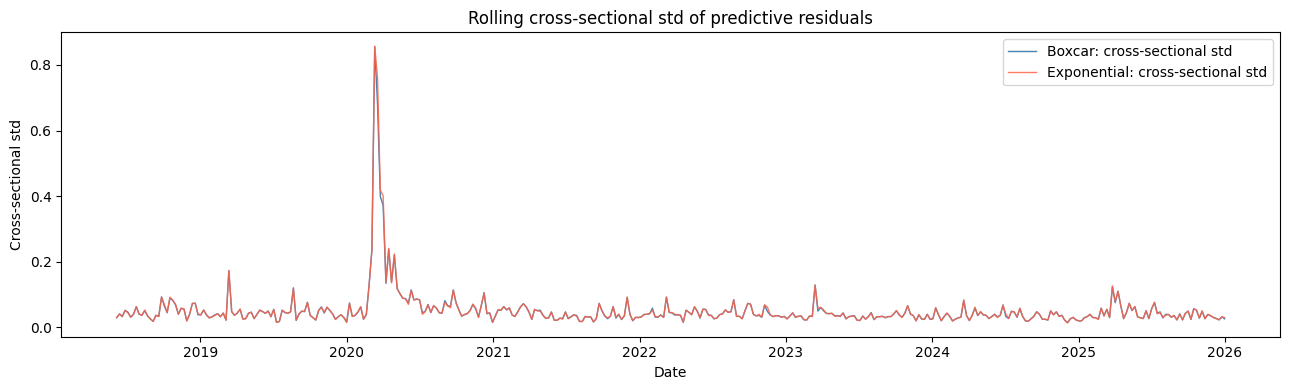

In [18]:
# --- Distribution & Variance: Pooled (Unpaired) Tests ---
# Kolmogorov–Smirnov test: checks if residuals come from the same distribution
ks_stat, ks_p = ks_2samp(q_box_pool, q_exp_pool)
# Levene’s test: compares the variances of residuals
lev_stat, lev_p = levene(q_box_pool, q_exp_pool)

pooled_tests_df = pd.DataFrame({
    "Statistic": ["Kolmogorov–Smirnov", "Levene variance"],
    "Value": [ks_stat, lev_stat],
    "p-value": [ks_p, lev_p],
}).set_index("Statistic")
pooled_tests_styled = pooled_tests_df.style.set_caption("Pooled (unpaired) tests of residuals").set_table_attributes('style="width:50%"')
display(pooled_tests_styled)

# --- Paired Test: Squared Error Comparison for Each (Ticker, Date) ---
# Select complete rows for relevant columns
paired = panel[['date', 'ticker', 'q_box', 'q_exp']].dropna().copy()
paired_valid = paired.dropna(subset=['q_box', 'q_exp'])

# Squared residual difference per matched observation
sq_diff = paired_valid['q_box'] ** 2 - paired_valid['q_exp'] ** 2

paired_stats_df = None
if len(sq_diff) > 10:
    wilcox_stat, wilcox_p = wilcoxon(sq_diff)
    n_pairs = len(sq_diff)
    mean_diff = sq_diff.mean()
    n_pos = (sq_diff > 0).sum()
    n_neg = (sq_diff < 0).sum()
    pct_pos = 100 * (sq_diff > 0).mean()
    pct_neg = 100 * (sq_diff < 0).mean()
    paired_stats_df = pd.DataFrame({
        "Value": [
            n_pairs,
            wilcox_stat,
            wilcox_p,
            mean_diff,
            n_pos,
            pct_pos,
            n_neg,
            pct_neg
        ]
    }, index=[
        "Number of pairs",
        "Wilcoxon statistic",
        "Wilcoxon p-value",
        "Mean (q_box² - q_exp²)",
        "Positive (box > exp) count",
        "Positive (box > exp) %",
        "Negative (exp > box) count",
        "Negative (exp > box) %"
    ])
    paired_stats_styled = paired_stats_df.T.style.set_caption("Paired Wilcoxon on (q_box² - q_exp²)").set_table_attributes('style="width:75%"')
    display(paired_stats_styled)

# --- Rolling (By-Date) Cross-Sectional Standard Deviation of Residuals ---
weekly_std = (
    panel.groupby('date')[['q_box', 'q_exp']]
    .std()
    .dropna()
)
weekly_std.index = pd.to_datetime(weekly_std.index)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(
    weekly_std.index, weekly_std['q_box'],
    lw=1.0, color='steelblue',
    label='Boxcar: cross-sectional std'
)
ax.plot(
    weekly_std.index, weekly_std['q_exp'],
    lw=1.0, color='tomato', alpha=0.85,
    label='Exponential: cross-sectional std'
)
ax.set_title('Rolling cross-sectional std of predictive residuals')
ax.set_xlabel('Date')
ax.set_ylabel('Cross-sectional std')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## Summary of findings

### Results summary

#### Stage 1 — Contemporaneous hedging (K = 16, no intercept)
- The rolling contemporaneous model strips out the common equity and index-credit components of CDS spread returns. This produces **hedged CDS residuals** $\rho_{E,n}$ and **idiosyncratic equity residuals** $c_{E,n}$, which are the inputs to Stage 2.

#### Stage 2 — Predictive regression (no intercept)

$$
\rho_{E,n} \sim c_{E,n-1}, \qquad q_{E,n} = \rho_{E,n} - \mu_{E,n-1} \, c_{E,n-1}
$$

- **Predictive residuals $q$, pooled across tickers and dates (N = 6,641):**

| Metric            | Boxcar      | Exponential  |
|-------------------|------------:|-------------:|
| Mean              | -0.000442   | -0.000609    |
| Std               | 0.079501    | 0.081983     |
| Median            | -0.001361   | -0.001377    |
| Excess kurtosis   | 272.002028  | 314.656713   |

- **Weekly cross-sectional MSE (396 weeks):**

$$
\Delta_t = \text{MSE}^{exp}_t - \text{MSE}^{box}_t \quad (\Delta_t < 0 \Rightarrow \text{Exponential better})
$$

  - Exponential better: **192 / 396 weeks (48.5%)**
  - Boxcar better: **204 / 396 weeks (51.5%)**
  - Average $\Delta\text{MSE}$: **+0.000396**

- **Per-ticker MSE (ticker-level average over time; 17 tickers):**
  - Exponential better: **2 / 17 (11.8%)**
  - Boxcar better: **15 / 17 (88.2%)**

- **Boxcar $q$ vs Exponential $q$: formal tests**

| Test            | Statistic   | p-value    |
|-----------------|------------:|-----------:|
| KS (distribution) | 0.004668  | 1.000000   |
| Levene (variance) | 0.033108  | 0.855620   |

Paired squared-error comparison (matched ticker-date pairs, N = 6,641):
- Wilcoxon p-value: **0.753685**
- Mean $(q_{box}^2 - q_{exp}^2)$: **-0.000401**
- Box better: **3356 (50.53%)**; Exp better: **3285 (49.47%)**

- **Predictive coefficient $\mu$, pooled across tickers and dates (N = 6,658):**

| Metric            | $\mu$ Boxcar | $\mu$ Exponential |
|-------------------|-------------:|------------------:|
| Mean              | -0.147568    | -0.147063         |
| Std               | 0.449045     | 0.464821          |
| Median            | -0.126519    | -0.130810         |
| Excess kurtosis   | 18.366660    | 30.649437         |

---

### Economic interpretation

- **Lead–lag / delayed incorporation:** $\mu < 0$ means **positive idiosyncratic equity moves** $(c_{E,n-1} > 0)$ are followed by **idiosyncratic CDS tightening** $(\rho_{E,n} < 0)$ in the next week.

---

### Learnings

- After contemporaneous hedging, week-ahead prediction errors $q$ are dominated by tail events (excess kurtosis $\gg 0$).
- Boxcar and Exponential residuals are statistically indistinguishable in the pooled distribution and variance (KS and Levene do not reject).

---

### Insights

- Equity moves incorporate firm-specific information faster than CDS; credit adjusts with a lag (negative $\mu$).
- Exponential weights increase coefficient variability (higher $\mu$ std) without delivering a stable MSE edge in this sample.
- All tickers but 2 have lower MSE with Boxcar compared with exponential weighting.